In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df = pd.read_csv("final_data.csv")
df.head()

,date,darshans,weekend,weekday,summer,temp_max,temp_min,humidity,rainfall,rolling_avg_8,google_trend_score,is_public_holiday,is_festival,is_brahmostavam,rolling_avg_7,day,month
0,2013-10-16,63426,0,1,0,31.5,24.3,80,4.7,58666.25,60,1,0,0,61020.571429,16,10
1,2013-10-17,56136,0,1,0,30.9,23.4,83,1.0,58666.25,80,0,0,0,61020.571429,17,10
2,2013-10-18,62341,0,1,0,30.5,24.1,81,0.4,58666.25,50,0,0,0,61020.571429,18,10
3,2013-10-19,71231,1,0,0,30.8,24.0,80,1.1,58666.25,53,0,0,0,61020.571429,19,10
4,2013-10-20,72279,1,0,0,25.4,23.3,92,8.8,58666.25,39,0,0,0,61020.571429,20,10


In [5]:
df.shape

(3572, 17)

In [6]:
df.isnull().sum()

date                  0
darshans              0
weekend               0
weekday               0
summer                0
temp_max              0
temp_min              0
humidity              0
rainfall              0
rolling_avg_8         0
google_trend_score    0
is_public_holiday     0
is_festival           0
is_brahmostavam       0
rolling_avg_7         0
day                   0
month                 0
dtype: int64

In [7]:
df.describe()

,darshans,weekend,weekday,summer,temp_max,temp_min,humidity,rainfall,rolling_avg_8,google_trend_score,is_public_holiday,is_festival,is_brahmostavam,rolling_avg_7,day,month
count,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000,3572.000000
mean,68172.339866,0.288074,0.427212,0.223684,32.982055,23.120241,68.433651,2.655207,68143.081362,40.447928,0.044513,0.064950,0.020997,68150.534714,15.606943,6.376260
std,13279.564817,0.452929,0.494743,0.416771,4.081237,3.340806,12.623107,7.615653,10308.659192,23.715287,0.206260,0.246471,0.143393,10336.329126,8.716869,3.599072
min,29295.000000,0.000000,0.000000,0.000000,22.700000,14.000000,30.000000,0.000000,30134.375000,0.000000,0.000000,0.000000,0.000000,30076.857143,1.000000,1.000000
25%,60921.250000,0.000000,0.000000,0.000000,29.500000,20.600000,59.000000,0.000000,64414.343750,21.000000,0.000000,0.000000,0.000000,64481.214286,8.000000,3.000000
50%,68443.000000,0.000000,0.000000,0.000000,32.900000,23.700000,69.000000,0.100000,69402.250000,35.000000,0.000000,0.000000,0.000000,69465.428571,16.000000,6.000000
75%,76911.000000,1.000000,1.000000,0.000000,36.200000,25.700000,78.000000,1.800000,74159.562500,60.000000,0.000000,0.000000,0.000000,74272.107143,23.000000,10.000000
max,110662.000000,1.000000,1.000000,1.000000,44.600000,30.800000,98.000000,138.200000,92813.875000,100.000000,1.000000,1.000000,1.000000,93765.285714,31.000000,12.000000


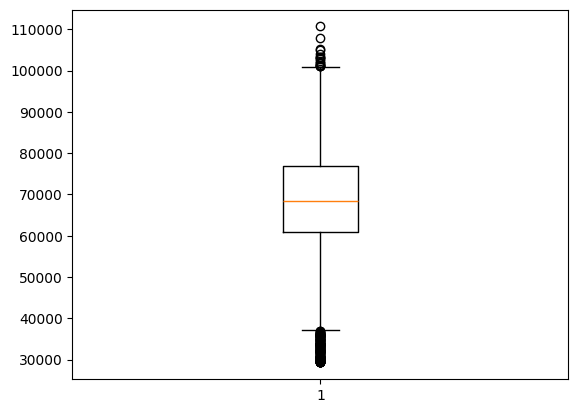

In [8]:
plt.boxplot(df['darshans'])
plt.show()


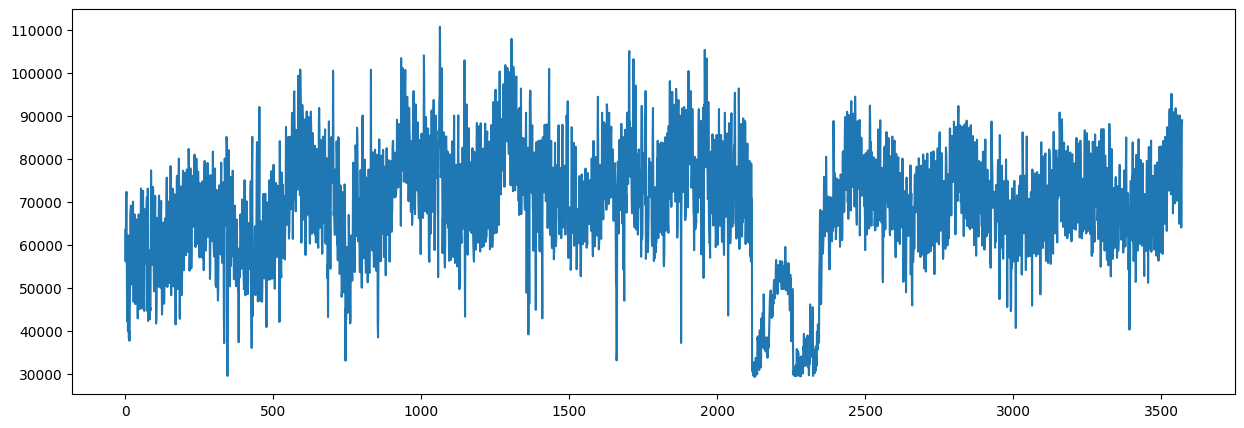

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['darshans'])
plt.show()


In [10]:

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Keep only post-COVID data
df = df[df['date'] >= '2022-03-01'].copy()

# Add lag feature
df['lag_1'] = df['darshans'].shift(1)

# Create cyclical month features
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Remove unnecessary columns
df.drop(
    columns=[
        'weekday',
        'rolling_avg_8',
        'day',
        'month'
    ],
    inplace=True
)

# Remove NaN rows created by lag_1
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

# Save processed dataset
output_path = "tirupati_post_covid_processed.csv"

os.makedirs("processed_data", exist_ok=True)

df.to_csv(output_path, index=False)

print(f"Saved successfully to: {output_path}")
print(df.head())

Saved successfully to: tirupati_post_covid_processed.csv
        date  darshans  weekend  summer  temp_max  temp_min  humidity  \
0 2022-03-02     46172        0       0      33.5      18.1        49   
1 2022-03-03     50511        0       0      31.8      18.7        59   
2 2022-03-04     56686        0       0      32.8      19.5        66   
3 2022-03-05     67750        1       0      32.7      20.5        67   
4 2022-03-06     61052        1       0      31.7      20.6        65   

   rainfall  google_trend_score  is_public_holiday  is_festival  \
0       0.0                   6                  0            0   
1       0.0                   5                  0            0   
2       0.0                   5                  0            0   
3       0.0                   5                  0            0   
4       0.1                   6                  0            0   

   is_brahmostavam  rolling_avg_7    lag_1  month_sin     month_cos  
0                0   55715.5714

In [11]:
df.shape

(1221, 16)

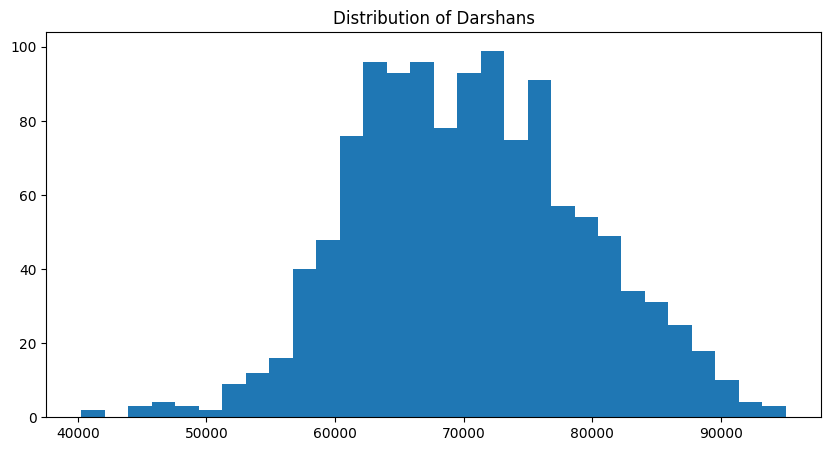

In [12]:
plt.figure(figsize=(10,5))
plt.hist(df['darshans'], bins=30)
plt.title("Distribution of Darshans")
plt.show()

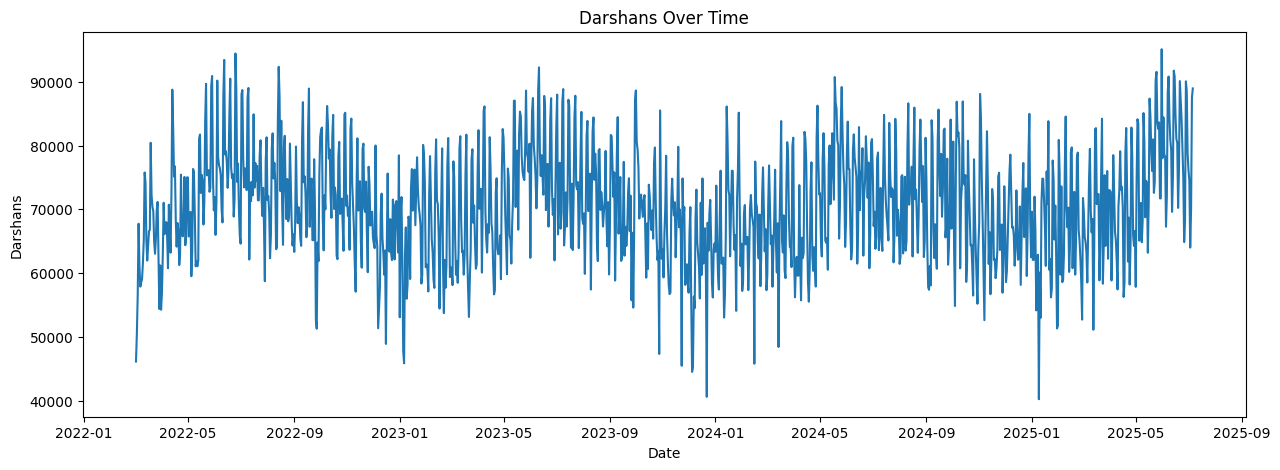

In [13]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['darshans'])
plt.title("Darshans Over Time")
plt.xlabel("Date")
plt.ylabel("Darshans")
plt.show()

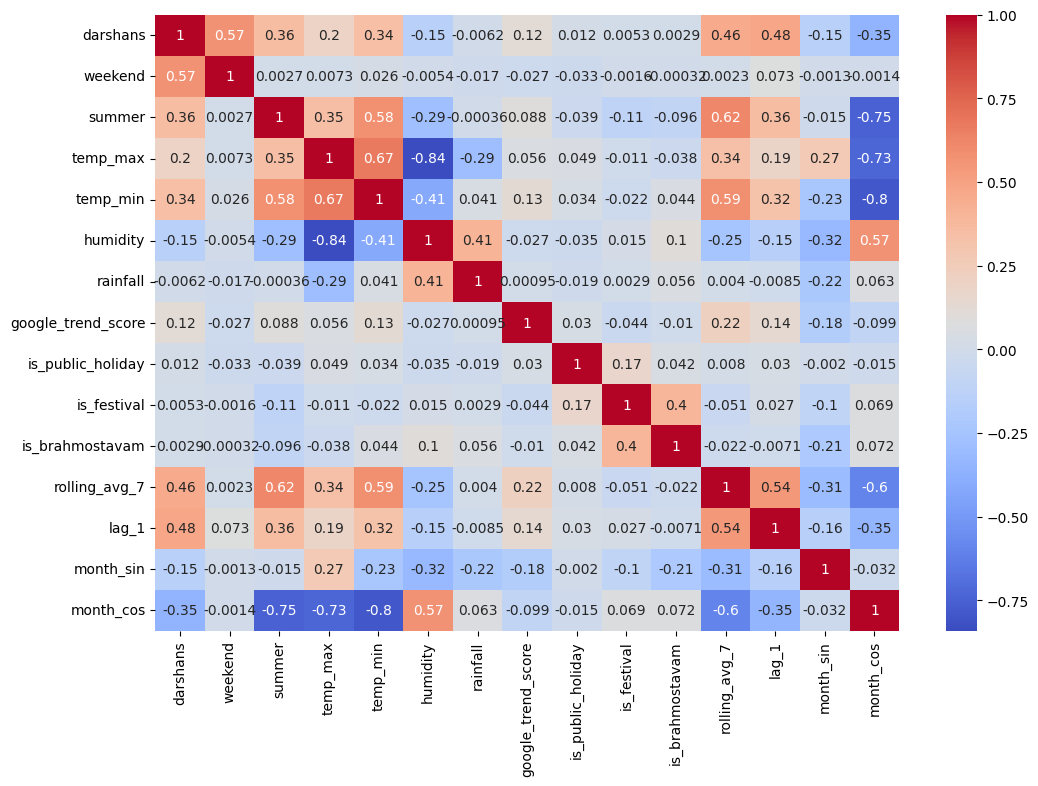

In [14]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.show()

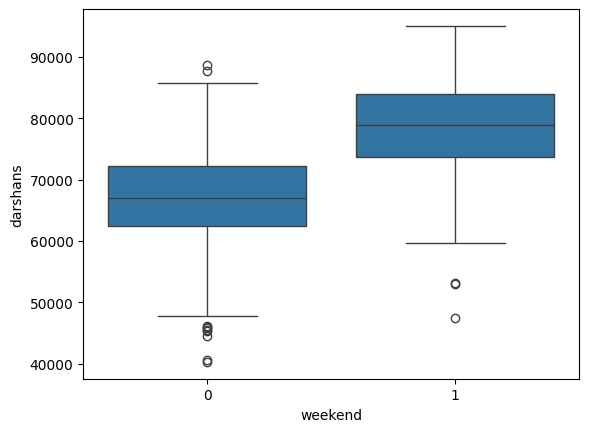

In [15]:
sns.boxplot(x='weekend', y='darshans', data=df)
plt.show()

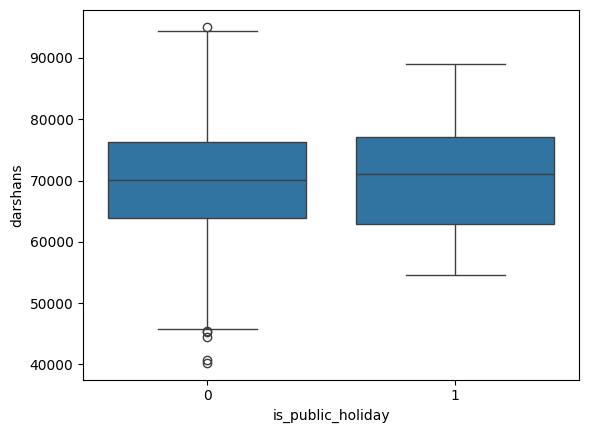

In [16]:
sns.boxplot(
    x='is_public_holiday',
    y='darshans',
    data=df
)
plt.show()

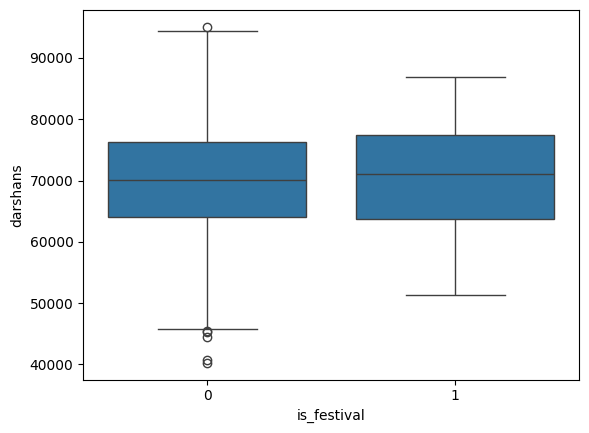

In [17]:
sns.boxplot(
    x='is_festival',
    y='darshans',
    data=df
)
plt.show()

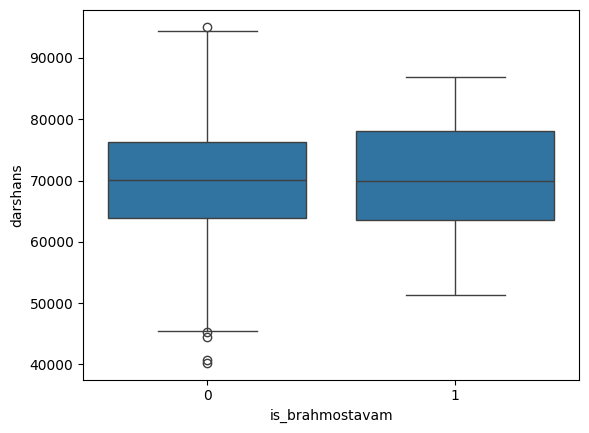

In [18]:
sns.boxplot(
    x='is_brahmostavam',
    y='darshans',
    data=df
)
plt.show()

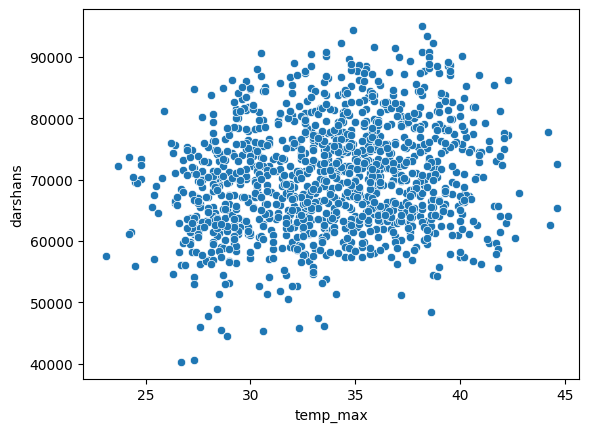

In [19]:
sns.scatterplot(
    x='temp_max',
    y='darshans',
    data=df
)
plt.show()

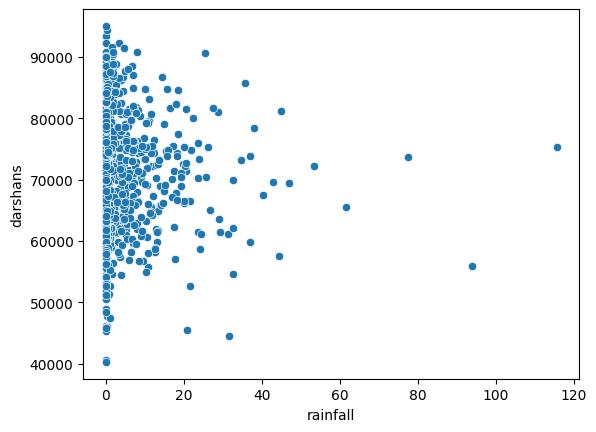

In [20]:
sns.scatterplot(
    x='rainfall',
    y='darshans',
    data=df
)
plt.show()

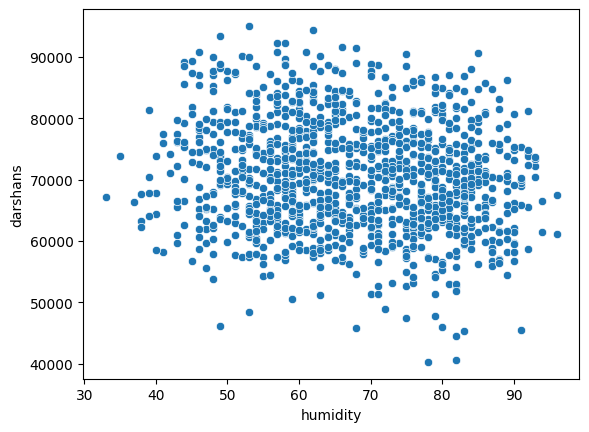

In [21]:
sns.scatterplot(
    x='humidity',
    y='darshans',
    data=df
)
plt.show()

In [22]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['darshans'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.7937898304466775
p-value: 0.059166336792605974


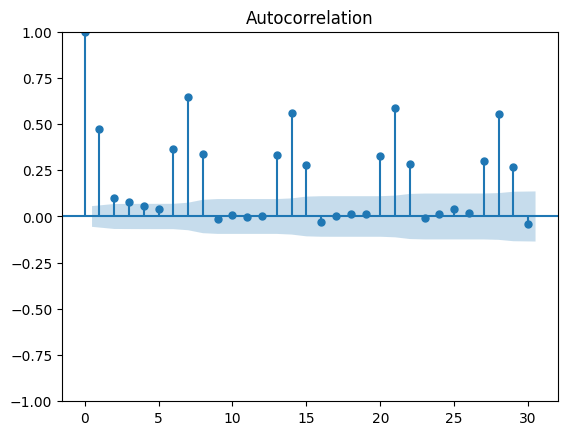

In [23]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['darshans'], lags=30)
plt.show()

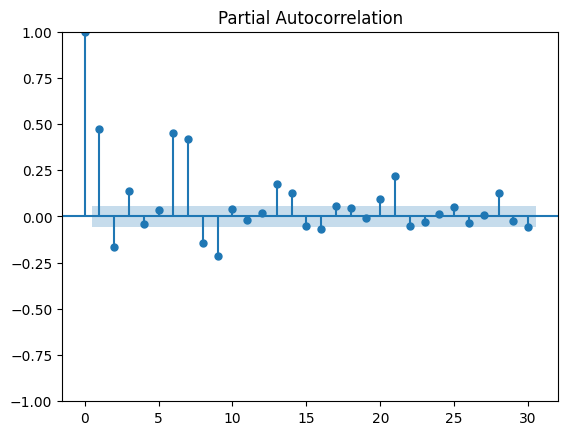

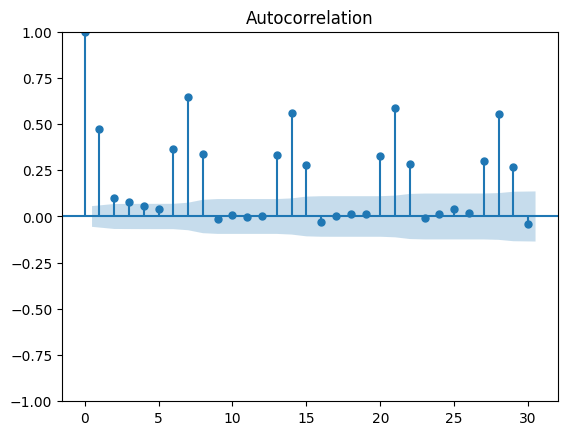

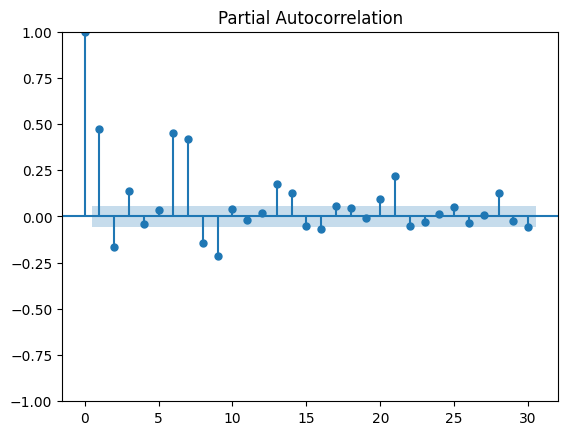

In [24]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(df['darshans'], lags=30)
plot_pacf(df['darshans'], lags=30)

In [25]:
TEST_DAYS = 30
VAL_DAYS = 60

test = df.iloc[-TEST_DAYS:]

validation = df.iloc[-(TEST_DAYS + VAL_DAYS):-TEST_DAYS]

train = df.iloc[:-(TEST_DAYS + VAL_DAYS)]

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

print("\nTrain Range")
print(train['date'].min(), "->", train['date'].max())

print("\nValidation Range")
print(validation['date'].min(), "->", validation['date'].max())

print("\nTest Range")
print(test['date'].min(), "->", test['date'].max())

Train: (1131, 16)
Validation: (60, 16)
Test: (30, 16)

Train Range
2022-03-02 00:00:00 -> 2025-04-07 00:00:00

Validation Range
2025-04-08 00:00:00 -> 2025-06-06 00:00:00

Test Range
2025-06-07 00:00:00 -> 2025-07-06 00:00:00


In [26]:
TARGET = "darshans"

FEATURES = [
    'weekend',
    'summer',
    'temp_max',
    'temp_min',
    'humidity',
    'rainfall',
    'google_trend_score',
    'is_public_holiday',
    'is_festival',
    'is_brahmostavam',
    'rolling_avg_7',
    'lag_1',
    'month_sin',
    'month_cos'
]

In [27]:
import pandas as pd
import pickle
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Combine train and validation data
train_val = pd.concat(
    [train, validation],
    ignore_index=True
)

print(f"Training rows: {len(train_val)}")

# Train final model
final_model = SARIMAX(
    train_val[TARGET],
    exog=train_val[FEATURES],
    order=(6,0,6),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model_fit = final_model.fit(
    disp=False
)

print("Final model trained successfully!")

# Save both model and feature list
artifacts = {
    "model": final_model_fit,
    "features": FEATURES
}

with open(
    "sarimax_model.pkl",
    "wb"
) as f:
    pickle.dump(
        artifacts,
        f
    )

print("Model saved as sarimax_model.pkl")

Training rows: 1191


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Final model trained successfully!
Model saved as sarimax_model.pkl


In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

history = train.copy()

val_predictions = []

for i in range(len(validation)):

    model = SARIMAX(
        history[TARGET],
        exog=history[FEATURES],
        order=(6,0,6),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    next_exog = validation[FEATURES].iloc[i:i+1]

    pred = fitted.forecast(
        steps=1,
        exog=next_exog
    )

    val_predictions.append(
        pred.iloc[0]
    )

    history = pd.concat(
        [history, validation.iloc[i:i+1]],
        ignore_index=True
    )

print(
    f"Generated {len(val_predictions)} validation predictions"
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

Generated 60 validation predictions


In [29]:
validation_results = pd.DataFrame({
    "actual": validation[TARGET].values,
    "predicted": val_predictions
})

under_predictions = validation_results[
    validation_results["actual"] >
    validation_results["predicted"]
].copy()

under_predictions["gap"] = (
    under_predictions["actual"] -
    under_predictions["predicted"]
)

buffer_70 = (
    under_predictions["gap"]
    .quantile(0.70)
)

print(
    f"70th Percentile Buffer = {buffer_70:.2f}"
)

70th Percentile Buffer = 4976.28


In [30]:
artifacts = {
    "model": final_model_fit,
    "features": FEATURES,
    "buffer": buffer_70
}

with open(
    "sarimax_model.pkl",
    "wb"
) as f:
    pickle.dump(
        artifacts,
        f
    )

In [31]:
import pickle

artifacts = {
    "model": final_model_fit,
    "features": FEATURES,
    "buffer": buffer_70
}

with open(
    "sarimax_model.pkl",
    "wb"
) as f:
    pickle.dump(
        artifacts,
        f
    )

print("Model and buffer saved successfully!")

Model and buffer saved successfully!


In [32]:
import pickle

with open(
    "sarimax_model.pkl",
    "rb"
) as f:
    artifacts = pickle.load(f)

loaded_model = artifacts["model"]
loaded_features = artifacts["features"]
loaded_buffer = artifacts["buffer"]

print("Model Loaded Successfully")
print("Buffer:", loaded_buffer)
print("Features:", loaded_features)

Model Loaded Successfully
Buffer: 4976.282665850501
Features: ['weekend', 'summer', 'temp_max', 'temp_min', 'humidity', 'rainfall', 'google_trend_score', 'is_public_holiday', 'is_festival', 'is_brahmostavam', 'rolling_avg_7', 'lag_1', 'month_sin', 'month_cos']


In [33]:
X_next = train_val[
    FEATURES
].tail(1)

forecast = loaded_model.forecast(
    steps=1,
    exog=X_next
)

base_prediction = forecast.iloc[0]

safe_prediction = (
    base_prediction +
    loaded_buffer
)

print(
    f"Base Forecast: {base_prediction:.0f}"
)

print(
    f"Safe Forecast: {safe_prediction:.0f}"
)

Base Forecast: 70953
Safe Forecast: 75929


In [34]:
validation_results = pd.DataFrame({
    "actual": validation[TARGET].values,
    "predicted": val_predictions
})

validation_results[
    "safe_prediction"
] = (
    validation_results[
        "predicted"
    ] + buffer_70
)

original_under_rate = (
    (
        validation_results[
            "predicted"
        ]
        <
        validation_results[
            "actual"
        ]
    ).mean()
) * 100

safe_under_rate = (
    (
        validation_results[
            "safe_prediction"
        ]
        <
        validation_results[
            "actual"
        ]
    ).mean()
) * 100

print(
    f"Original Underprediction Rate: "
    f"{original_under_rate:.2f}%"
)

print(
    f"Safe Underprediction Rate: "
    f"{safe_under_rate:.2f}%"
)

Original Underprediction Rate: 61.67%
Safe Underprediction Rate: 18.33%


In [35]:
mape_before = np.mean(
    np.abs(
        (
            validation_results["actual"]
            -
            validation_results["predicted"]
        )
        /
        validation_results["actual"]
    )
) * 100

mape_after = np.mean(
    np.abs(
        (
            validation_results["actual"]
            -
            validation_results["safe_prediction"]
        )
        /
        validation_results["actual"]
    )
) * 100

print(
    f"MAPE Before Buffer: {mape_before:.2f}%"
)

print(
    f"MAPE After Buffer: {mape_after:.2f}%"
)

MAPE Before Buffer: 4.79%
MAPE After Buffer: 6.64%


In [36]:
validation_results.to_csv(
    "validation_analysis.csv",
    index=False
)

print(
    "validation_analysis.csv saved"
)

validation_analysis.csv saved


In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

history = train_val.copy()

test_predictions = []
safe_predictions = []

for i in range(len(test)):

    model = SARIMAX(
        history[TARGET],
        exog=history[FEATURES],
        order=(6,0,6),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    next_exog = test[FEATURES].iloc[i:i+1]

    pred = fitted.forecast(
        steps=1,
        exog=next_exog
    )

    base_pred = pred.iloc[0]

    safe_pred = (
        base_pred + buffer_70
    )

    test_predictions.append(
        base_pred
    )

    safe_predictions.append(
        safe_pred
    )

    history = pd.concat(
        [history, test.iloc[i:i+1]],
        ignore_index=True
    )

print("Test predictions completed")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

Test predictions completed


In [38]:
test_results = pd.DataFrame({
    "date": test["date"].values,
    "actual": test[TARGET].values,
    "predicted": test_predictions,
    "safe_prediction": safe_predictions,
    "weekend": test["weekend"].values
})

test_results.head()

,date,actual,predicted,safe_prediction,weekend
0,2025-06-07,88257,88976.895131,93953.177797,1
1,2025-06-08,90802,85309.832187,90286.114853,1
2,2025-06-09,84258,79779.146489,84755.429155,0
3,2025-06-10,80894,80279.131851,85255.414517,0
4,2025-06-11,79296,79788.461024,84764.743690,0


In [39]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test_results["actual"],
    test_results["safe_prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_results["actual"],
        test_results["safe_prediction"]
    )
)

mape = np.mean(
    np.abs(
        (
            test_results["actual"]
            -
            test_results["safe_prediction"]
        )
        /
        test_results["actual"]
    )
) * 100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2))

MAE : 4947.69
RMSE: 5513.15
MAPE: 6.4


In [40]:
test_results["underpredict"] = (
    test_results["safe_prediction"]
    <
    test_results["actual"]
)

under_count = (
    test_results["underpredict"]
    .sum()
)

total = len(test_results)

under_rate = (
    under_count / total
) * 100

print(
    f"Underpredictions: "
    f"{under_count}/{total}"
)

print(
    f"Underprediction Rate: "
    f"{under_rate:.2f}%"
)

Underpredictions: 1/30
Underprediction Rate: 3.33%


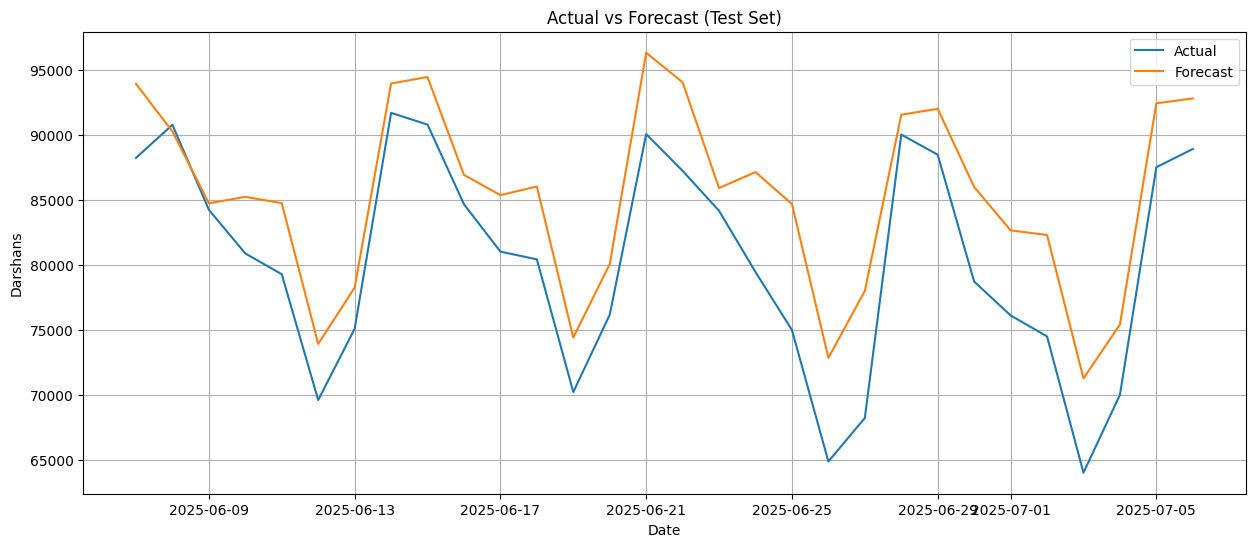

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    test_results["date"],
    test_results["actual"],
    label="Actual"
)

plt.plot(
    test_results["date"],
    test_results["safe_prediction"],
    label="Forecast"
)

plt.title(
    "Actual vs Forecast (Test Set)"
)

plt.xlabel("Date")
plt.ylabel("Darshans")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
test_results[
    [
        "date",
        "actual",
        "predicted",
        "safe_prediction"
    ]
].head(30)

,date,actual,predicted,safe_prediction
0,2025-06-07,88257,88976.895131,93953.177797
1,2025-06-08,90802,85309.832187,90286.114853
2,2025-06-09,84258,79779.146489,84755.429155
3,2025-06-10,80894,80279.131851,85255.414517
4,2025-06-11,79296,79788.461024,84764.743690
5,2025-06-12,69609,68955.803379,73932.086045
6,2025-06-13,75096,73288.968006,78265.250672
7,2025-06-14,91720,89003.268949,93979.551615
8,2025-06-15,90815,89502.648524,94478.931190
9,2025-06-16,84681,81965.550002,86941.832668
